In [1]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df.shape

(284807, 31)

In [3]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [4]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
df['Amount'].value_counts()

Amount
1.00      13688
1.98       6044
0.89       4872
9.99       4747
15.00      3280
          ...  
787.95        1
405.09        1
381.05        1
337.54        1
95.63         1
Name: count, Length: 32767, dtype: int64

In [9]:
df.groupby('Class')['Amount'].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

In [7]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


<Axes: xlabel='Hour'>

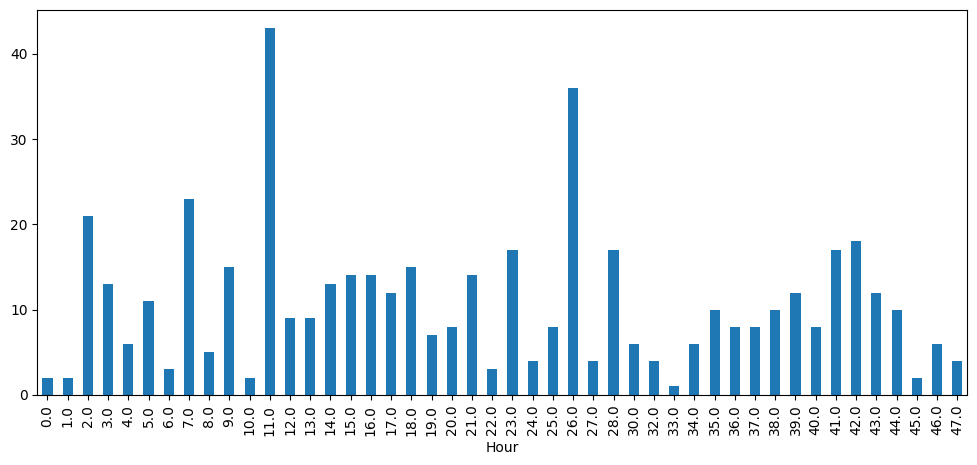

In [8]:
df['Hour'] = df['Time'] // 3600

fraud_by_hour = df[df['Class'] == 1].groupby('Hour').size()

fraud_by_hour.plot(kind='bar', figsize=(12,5))

In [10]:
# Calculate how much each feature relates to 'Class' (Fraud)
correlations = df.corr()['Class'].sort_values(ascending=False)

# Look at the top and bottom results
print("Features most positively correlated with Fraud:")
print(correlations.head(5))

print("\nFeatures most negatively correlated with Fraud:")
print(correlations.tail(5))

Features most positively correlated with Fraud:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
Name: Class, dtype: float64

Features most negatively correlated with Fraud:
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


In [1]:
import joblib

# 1. Load the file
package = joblib.load('model_v2023.pkl')

# 2. Inspect the keys
print("Keys in the file:", package.keys())

# 3. Inspect the features it chose
print("The 10 Red Flags chosen by the model:", package['features'])

# 4. Inspect the model parameters
print("The Model details:", package['model'])

Keys in the file: dict_keys(['model', 'features'])
The 10 Red Flags chosen by the model: ['V14', 'V12', 'V4', 'V11', 'V3', 'V10', 'V9', 'V16', 'V1', 'V2']
The Model details: RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)
